In [2]:
!pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (28 kB)
  Using cached https://download-r2.pytorch.org/whl/cu118/torchvision-0.22.1%2Bcu118-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.1 kB)
  Using cached https://download-r2.pytorch.org/whl/cu118/torchaudio-2.7.1%2Bcu118-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached https://download.pytorch.org/whl/setuptools-70.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-n

In [3]:
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [19]:
import os, sys, json, time, random, math
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models.video as video_models

torch.backends.cudnn.benchmark = True 
torch.backends.cudnn.deterministic = False


In [20]:
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else 'cpu'
)
print(f'PyTorch {torch.__version__}  |  device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch 2.7.1+cu118  |  device: cuda
GPU: Tesla P100-PCIE-16GB


# Global Configurations

In [30]:
DATA_DIR   = '/kaggle/input/datasets/mennaezzelarab/shop-dataset/Shop DataSet'

# Training Hyperparameters for Transfer Learning
N_FRAMES    = 16      # R(2+1)D handles 16 well and it's faster
IMG_SIZE    = 112     # Native resolution for pretrained R(2+1)D
BATCH_SIZE  = 8       # Optimal for Kaggle T4/P100 memory
MAX_EPOCHS = 15      # Transfer learning converges faster
PATIENCE   = 5
TEST_SPLIT  = 0.20    # 80/20 train/test split as requested
SEED        = 42

# Differential Learning Rates
LR_BACKBONE = 1e-5   # Slow fine-tuning for movement features
LR_HEAD     = 1e-4   # Faster learning for your specific classes

SUPPORTED_EXTS = {'.mp4', '.avi', '.mov', '.mkv', '.wmv'}
CLASS_TO_IDX = {'non shop lifters': 0, 'shop lifters': 1}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print('Config loaded.')

Config loaded.


# Professional Video Dataset

In [22]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def _read_frames_uniform(cap, n):
    total = max(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), 1)
    idxs  = np.linspace(0, total - 1, n, dtype=int)
    frames = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        else:
            frames.append(frames[-1] if frames 
                          else np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8))
    return frames

def normalize_clip(frames, target_size):
    out = []
    for frame in frames:
        frame = cv2.resize(frame, (target_size, target_size))
        frame = frame.astype(np.float32) / 255.0
        frame = (frame - IMAGENET_MEAN) / IMAGENET_STD
        out.append(frame)
    return out

class VideoDataset(Dataset):
    def __init__(self, data_dir, n_frames=N_FRAMES, target_size=IMG_SIZE):
        self.n_frames     = n_frames
        self.target_size  = target_size
        self.samples      = []
        self._load(Path(data_dir))

    def _load(self, root):
        for cls_dir in sorted(root.iterdir()):
            if not cls_dir.is_dir(): continue
            label = CLASS_TO_IDX.get(cls_dir.name, -1)
            if label == -1: continue
            for f in cls_dir.rglob('*'):
                if f.suffix.lower() in SUPPORTED_EXTS:
                    self.samples.append((f, label))
        print(f'  VideoDataset: {len(self.samples)} videos found.')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        cap = cv2.VideoCapture(str(path))
        frames = _read_frames_uniform(cap, self.n_frames)
        cap.release()
        frames = normalize_clip(frames, self.target_size)
        arr = np.stack(frames, axis=0).astype(np.float32)
        # (T, H, W, C) -> (T, C, H, W)
        tensor = torch.from_numpy(arr).permute(0, 3, 1, 2)
        return tensor, label

# DataLoaders (80/20 Split)

In [23]:
def make_dataloaders(data_dir):
    full_ds = VideoDataset(data_dir)
    
    # Stratified 80/20 Split
    labels = [lbl for _, lbl in full_ds.samples]
    indices = np.arange(len(full_ds))
    
    from sklearn.model_selection import train_test_split
    train_idx, test_idx = train_test_split(
        indices, test_size=TEST_SPLIT, stratify=labels, random_state=SEED
    )

    train_ds = Subset(full_ds, train_idx)
    test_ds  = Subset(full_ds, test_idx)

    # Balance training set using WeightedRandomSampler
    tr_labels = [labels[i] for i in train_idx]
    counts = np.bincount(tr_labels)
    weights = 1. / counts
    sample_weights = [weights[l] for l in tr_labels]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    loaders = {
        'train': DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True),
        'test':  DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=4, pin_memory=True)
    }
    print(f'  Splits -> Train: {len(train_ds)} | Test: {len(test_ds)}')
    return loaders, full_ds, test_idx

loaders, full_ds, test_idx = make_dataloaders(DATA_DIR)

  VideoDataset: 855 videos found.
  Splits -> Train: 684 | Test: 171


# Pretrained R(2+1)D Model

In [25]:
class VideoTransferModel(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        # R3D_18 is the most stable choice for P100
        self.backbone = video_models.r3d_18(weights=video_models.R3D_18_Weights.DEFAULT)
        # --- LOCK THE BACKBONE (Feature Extraction) ---
        for param in self.backbone.parameters():
            param.requires_grad = False
        # Replace head (New head HAS requires_grad=True by default)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        # (Batch, Time, Channels, Height, Width) -> (Batch, Channels, Time, Height, Width)
        x = x.permute(0, 2, 1, 3, 4)
        return self.backbone(x)
model = VideoTransferModel().to(DEVICE)
print('Pretrained Model Loaded: Feature Extraction Mode Active (Backbone Locked).')

Pretrained Model Loaded: Feature Extraction Mode Active (Backbone Locked).


# Training Logic & Engines

In [28]:
def compute_metrics(probs, labels):
    preds = (probs >= 0.5).astype(int)
    from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
    return {
        'acc': accuracy_score(labels, preds),
        'prec': precision_score(labels, preds, zero_division=0),
        'rec': recall_score(labels, preds, zero_division=0),
        'f1': f1_score(labels, preds, zero_division=0)
    }

def run_pass(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    
    total_loss, all_probs, all_labels = 0.0, [], []
    # Use GradScaler for Mixed Precision
    scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None
    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.float().to(DEVICE)
            
            # Apply autocast for forward pass
            with torch.amp.autocast('cuda', enabled=(scaler is not None)):
                logits = model(x).squeeze(1)
                loss = criterion(logits, y)
            if is_train:
                optimizer.zero_grad()
                if scaler:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()
            total_loss += loss.item() * len(y)
            all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.append(y.cpu().numpy())
    probs = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    m = compute_metrics(probs, labels)
    m['loss'] = total_loss / len(labels)
    return m, probs, labels

optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], 
    lr=1e-4
)
criterion = nn.BCEWithLogitsLoss()

criterion = nn.BCEWithLogitsLoss()
best_f1 = 0.0
patience_ctr = 0

# Training Phase

In [31]:
print(f'\n{"Ep":>3} | {"TrLoss":>7} | {"TrF1":>6} | {"TrAcc":>6}')
print("-" * 35)
for epoch in range(1, MAX_EPOCHS + 1):
    # Train only
    tr, _, _ = run_pass(model, loaders['train'], criterion, optimizer)
    
    print(f'{epoch:3d} | {tr["loss"]:7.4f} | {tr["f1"]:6.4f} | {tr["acc"]:6.4f}')
    
    # Save the current state
    torch.save(model.state_dict(), 'final_theft_model.pt')
print("\n--- Training Complete ---")


 Ep |  TrLoss |   TrF1 |  TrAcc
-----------------------------------
  1 |  0.6599 | 0.7051 | 0.6257
  2 |  0.6124 | 0.7513 | 0.7251
  3 |  0.5597 | 0.7847 | 0.7939
  4 |  0.5310 | 0.7906 | 0.7792
  5 |  0.5023 | 0.7977 | 0.7939
  6 |  0.4748 | 0.8000 | 0.8070
  7 |  0.4367 | 0.8299 | 0.8304
  8 |  0.4333 | 0.8308 | 0.8202
  9 |  0.4530 | 0.8107 | 0.7939
 10 |  0.3948 | 0.8213 | 0.8333
 11 |  0.4225 | 0.8271 | 0.8246
 12 |  0.4046 | 0.8309 | 0.8333
 13 |  0.3558 | 0.8478 | 0.8509
 14 |  0.3981 | 0.8410 | 0.8275
 15 |  0.4088 | 0.8162 | 0.8275

--- Training Complete ---


# Final Evaluation & Confusion Matrix


--- FINAL TEST RESULTS ---
Final Accuracy:  92.40%
Final Precision: 85.14%
Final Recall:    96.92%
Final F1-Score:  90.65%


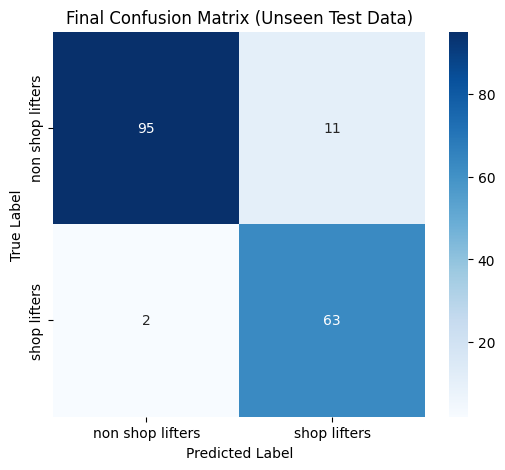


Detail Classification Report:
                  precision    recall  f1-score   support

non shop lifters       0.98      0.90      0.94       106
    shop lifters       0.85      0.97      0.91        65

        accuracy                           0.92       171
       macro avg       0.92      0.93      0.92       171
    weighted avg       0.93      0.92      0.92       171



In [32]:
model.load_state_dict(torch.load('final_theft_model.pt'))
print("\n--- FINAL TEST RESULTS ---")
m_test, probs, labels = run_pass(model, loaders['test'], criterion)
# Display Summary Metrics
print(f"Final Accuracy:  {m_test['acc']:.2%}")
print(f"Final Precision: {m_test['prec']:.2%}")
print(f"Final Recall:    {m_test['rec']:.2%}")
print(f"Final F1-Score:  {m_test['f1']:.2%}")
# Confusion Matrix
cm = confusion_matrix(labels, (probs >= 0.5).astype(int))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_TO_IDX.keys(), yticklabels=CLASS_TO_IDX.keys())
plt.title('Final Confusion Matrix (Unseen Test Data)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
print("\nDetail Classification Report:")
print(classification_report(labels, (probs >= 0.5).astype(int), target_names=CLASS_TO_IDX.keys()))

# Visualize Most Confident Theft Detections


Visualizing top-confident Shoplifting detections...


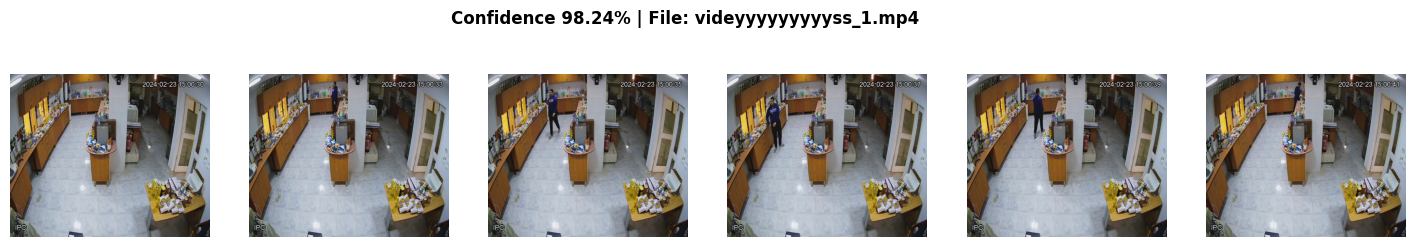

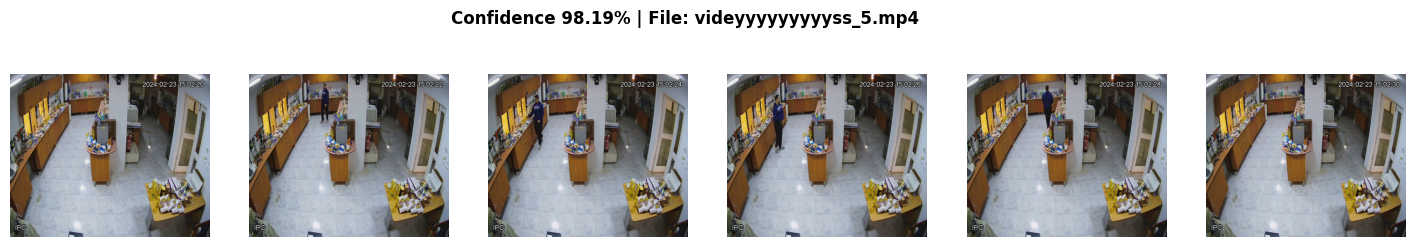

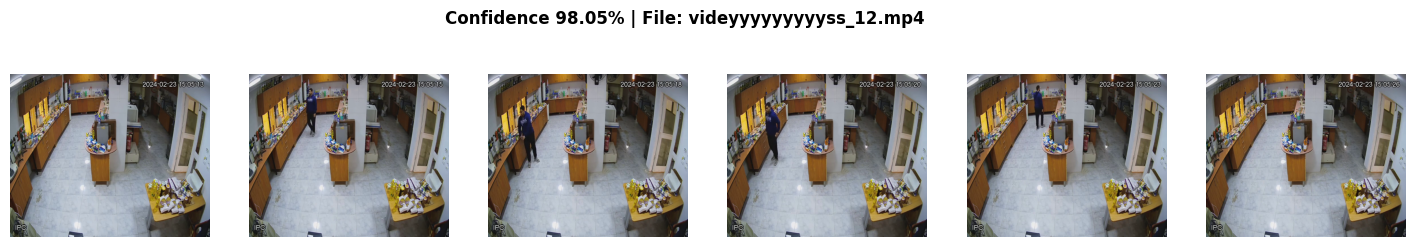

In [33]:
def visualize_top_theft(probs, labels, test_subset, n=3):
    # Filter only true shoplifters
    theft_indices = np.where(labels == 1)[0]
    theft_probs = probs[theft_indices]
    
    # Sort by confidence
    top_k_rel_indices = np.argsort(theft_probs)[::-1][:n]
    top_k_indices = theft_indices[top_k_rel_indices]
    
    for idx in top_k_indices:
        real_idx = test_subset.indices[idx]
        path, label = full_ds.samples[real_idx]
        
        cap = cv2.VideoCapture(str(path))
        frames = _read_frames_uniform(cap, 6) # pick 6 representative frames
        cap.release()
        
        fig, axes = plt.subplots(1, 6, figsize=(18, 3))
        fig.suptitle(f'Confidence {probs[idx]:.2%} | File: {path.name}', fontweight='bold')
        for ax, frame in zip(axes, frames):
            ax.imshow(frame)
            ax.axis('off')
        plt.show()

print("\nVisualizing top-confident Shoplifting detections...")
visualize_top_theft(probs, labels, loaders['test'].dataset)